In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [12]:
df = pd.read_csv('training.csv')

In [13]:
df

,id,dataset_id,title,content,classification
0,341cc34c0994933,2.0,Donald Trump pide que le encadenen en el sótan...,Donald Trump pide que le encadenen en el sótan...,real
1,3be5da55eb2ec93,2.0,Mattis says will try to work with Pakistan 'on...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,fake
2,gossipcop-890602,0.0,Bette Midler slams 'cheap' Hocus Pocus remake,NaN,real
3,de0a97e74559c40,1.0,SUNDAY SCREENING: The Deep State: Hiding in Pl...,Our weekly documentary screening curated by th...,fake
4,e4efe68210fc475,2.0,Ping-Pong as the Fountain of Youth - The New Y...,"I returned home the other night exhausted, qua...",fake
...,...,...,...,...,...
149044,90df729c97b86af,5.0,NIH study validates decontamination methods fo...,n95 respirators can be decontaminated effectiv...,real
149045,8630.json,4.0,"Even after collective bargaining reforms, most...",NaN,real
149046,2079723346611be,2.0,Paul Craig Roberts: ‘By Cooperating with Washi...,By Paul Crag RobertsA month ago I wrote a colu...,real
149047,75e8aaa299ee19d,2.0,China says has made best effort on North Korea...,BEIJING (Reuters) - A senior Chinese diplomat ...,fake


Columns found: ['id', 'dataset_id', 'title', 'content', 'classification']

--- Class Distribution ---
classification
real    79995
fake    69050
Name: count, dtype: int64

--- Percentage Split ---
classification
real    53.67171
fake    46.32829
Name: proportion, dtype: float64


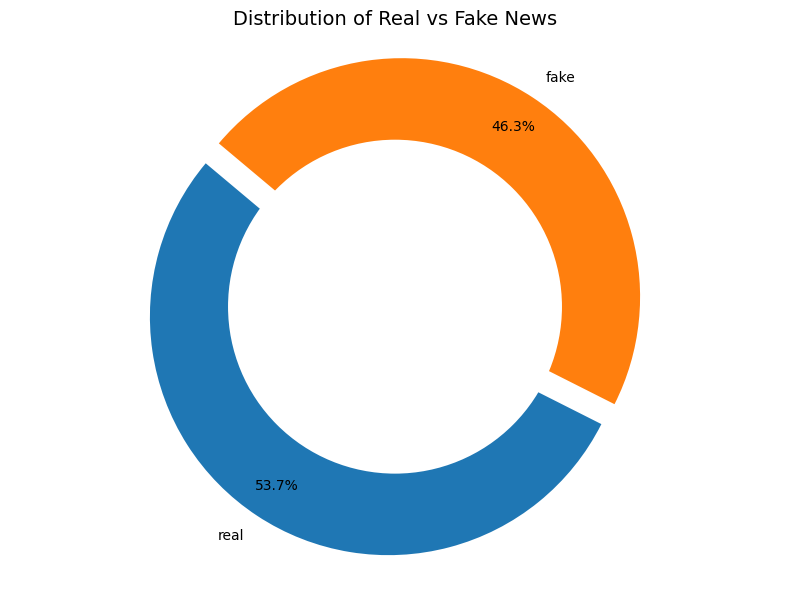

In [14]:
df.columns = df.columns.str.lower().str.strip()
TARGET_COLUMN = 'classification'
print("Columns found:", df.columns.tolist())
class_counts = df[TARGET_COLUMN].value_counts()
class_percents = df[TARGET_COLUMN].value_counts(normalize=True) * 100
print("\n--- Class Distribution ---")
print(class_counts)
print("\n--- Percentage Split ---")
print(class_percents)


plt.figure(figsize=(8, 6))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    explode=[0.05] * len(class_counts)
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Distribution of Real vs Fake News', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()


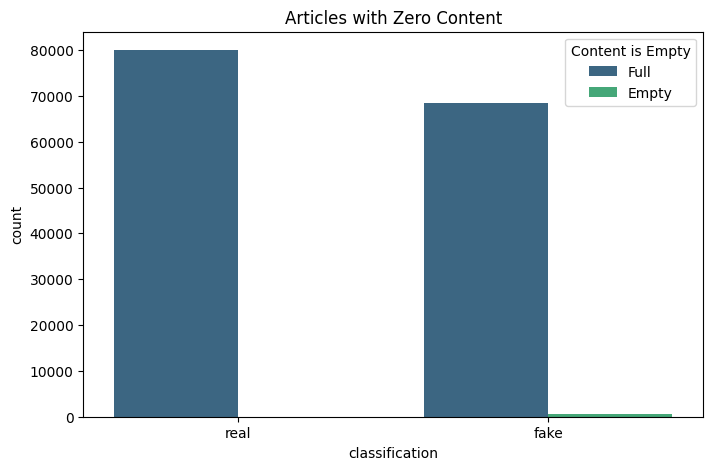

In [27]:
# both "real" and "fake" classifications have instances where the content is empty.
#However, professional news usually has a body, while gossip or social media "snippets" sometimes don't.

df['is_empty'] = df['content'].apply(lambda x: 1 if str(x).strip() == "" else 0)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='classification', hue='is_empty', palette='viridis')
plt.title('Articles with Zero Content')
plt.legend(title='Content is Empty', labels=['Full', 'Empty'])
plt.show()


Summary of Articles with Empty Content:

                total_articles  empty_articles  percentage_empty
classification                                                  
fake                     69050             558               0.8
real                     79995               1               0.0


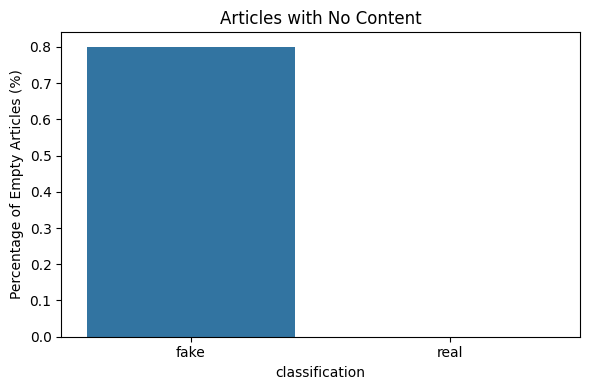

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['is_empty'] = df['content'].apply(
    lambda x: 1 if str(x).strip() == "" else 0
)

total_stats = (
    df.groupby('classification')['is_empty']
      .agg(
          total_articles='count',
          empty_articles='sum'
      )
)

total_stats['percentage_empty'] = (
    total_stats['empty_articles'] / total_stats['total_articles'] * 100
).round(1)

print("\nSummary of Articles with Empty Content:\n")
print(total_stats)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=total_stats.reset_index(),
    x='classification',
    y='percentage_empty'
)

plt.ylabel('Percentage of Empty Articles (%)')
plt.title('Articles with No Content')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipython-input-48841390.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='classification', y='bait_ratio', data=df, palette=custom_colors, ci=None)
/tmp/ipython-input-48841390.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='classification', y='bait_ratio', data=df, palette=custom_colors, ci=None)


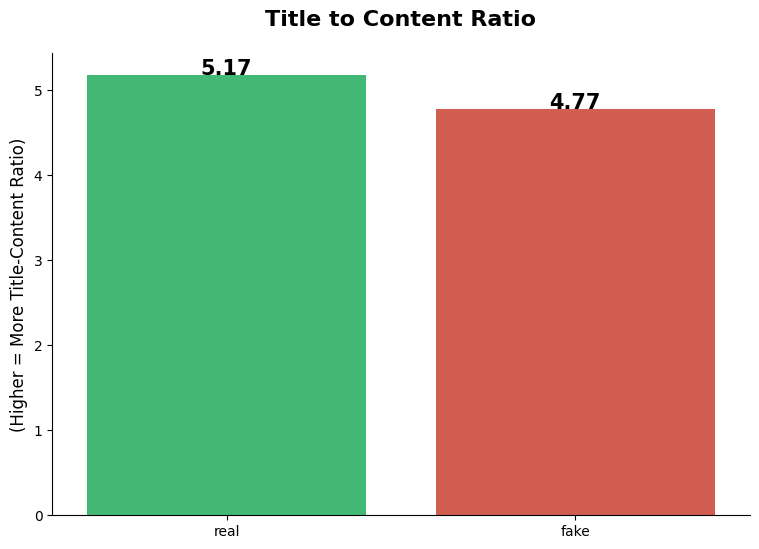

In [28]:
# My Assumption - Fake News sometimes has longer title than its acutal content to bait people into believing it
import matplotlib.pyplot as plt
import seaborn as sns


df['title_len'] = df['title'].str.len()
df['content_len'] = df['content'].str.len()
df['bait_ratio'] = df['title_len'] / (df['content_len'] + 1)

plt.figure(figsize=(9, 6))

custom_colors = {'real': '#2ecc71', 'fake': '#e74c3c'}
ax = sns.barplot(x='classification', y='bait_ratio', data=df, palette=custom_colors, ci=None)
plt.title('Title to Content Ratio', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('(Higher = More Title-Content Ratio)', fontsize=12)
plt.xlabel('')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.01,
            f'{height:.2f}', # Displays the number (e.g., 0.54)
            ha="center", fontsize=15, fontweight='bold')
sns.despine()
plt.show()

Average number of words in article content by class:
classification
fake    420.3
real    353.2
Name: content_word_count, dtype: float64


/tmp/ipython-input-1955157875.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_word_count.index, y=avg_word_count.values, palette='coolwarm')


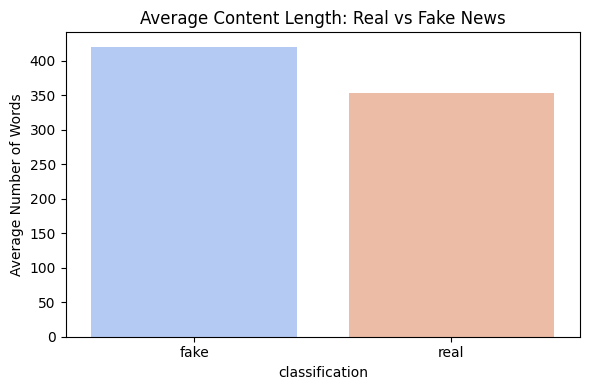

In [29]:
df['content'] = df['content'].astype(str)


df['content_word_count'] = df['content'].apply(lambda x: len(x.split()))

avg_word_count = df.groupby('classification')['content_word_count'].mean().round(1)


print("Average number of words in article content by class:")
print(avg_word_count)
plt.figure(figsize=(6, 4))
sns.barplot(x=avg_word_count.index, y=avg_word_count.values, palette='coolwarm')
plt.ylabel('Average Number of Words')
plt.title('Average Content Length: Real vs Fake News')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
